# Projet 4 
## Mission : Identifier les causes d'attrition

**Objectif du projet :**
Identifier les causes potentielles d’attrition au sein de l’ESN TechNova Partners à partir de données RH, d’évaluations de performance et d’un sondage de bien-être, en combinant analyse exploratoire, modélisation supervisée et interprétabilité des modèles.


**Sources :**
- SIRH : infos poste, âge, salaire, ancienneté, sociodémo
- Évaluations : notes performance + satisfaction
- Sondage : bien-être + indicateur de départ (cible)

**Livrables attendus :**

- Étape 1 : DataFrame central + Analyse exploratoire des données 
- Étape 2 : Préparer X (features prêtes sklearn) et y (cible) avec preprocessing (imputation/   encodage/scaling si besoin) reproductible.
- Étape 3 : Faire un premier benchmark classification (split stratifié + Dummy + linéaire + non-linéaire) + métriques train/test.
- Étape 4 : Améliorer l’approche (déséquilibre + CV stratifiée + seuil via courbe PR + éventuellement feature engineering).
- Étape 5 : Optimiser + interpréter (tuning hyperparamètres + importance globale + SHAP global/local + causes actionnables RH).

## Imports

In [1]:
import os
import sys

sys.path.append(os.path.abspath('..'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.processing import clean_columns


## Chargement des données

In [2]:
df_eval = pd.read_csv('../data/eval_data.csv')
df_sirh = pd.read_csv('../data/hr_data.csv')
df_sondage = pd.read_csv('../data/survey_data.csv')

# ÉTAPE 1: Analyse exploratoire des données

#### Affichage des 3 dataframes

In [3]:
print("EVAL:")
display(df_eval.head())
print("SIRH:")
display(df_sirh.head())
print("SONDAGE:")
display(df_sondage.head())

EVAL:


,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,eval_number,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente
0,2,3,2,4,1,1,E_1,3,Oui,11 %
1,3,2,2,2,4,3,E_2,4,Non,23 %
2,4,2,1,3,2,3,E_4,3,Oui,15 %
3,4,3,1,3,3,3,E_5,3,Oui,11 %
4,1,3,1,2,4,3,E_7,3,Non,12 %


SIRH:


,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,7
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,2,2


SONDAGE:


,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,Oui,0,0,1,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,Non,1,3,1,2,8,1,Infra & Cloud,Y,Frequent,1,7
2,Oui,0,3,1,4,2,2,Autre,Y,Occasionnel,0,0
3,Non,0,3,1,5,3,4,Infra & Cloud,Y,Frequent,3,0
4,Non,1,3,1,7,2,1,Transformation Digitale,Y,Occasionnel,2,2


## Analyse exploratoire

- Vérifier si les datasets contiennent le même ordre de grandeur d’observations.
- Le taux de valeurs manquantes.
- Le nombre de doublons.
- Identifier les colonnes constantes.

In [4]:
for name, df in [("SIRH", df_sirh), ("EVAL", df_eval), ("SONDAGE", df_sondage)]:
    print(f"\n{name}")
    print("Shape:", df.shape)
    print("Missing %:", round(df.isna().mean().max()*100, 2))
    print("Duplicated rows:", df.duplicated().sum())


SIRH
Shape: (1470, 12)
Missing %: 0.0
Duplicated rows: 0

EVAL
Shape: (1470, 10)
Missing %: 0.0
Duplicated rows: 0

SONDAGE
Shape: (1470, 12)
Missing %: 0.0
Duplicated rows: 0


In [5]:
for name, df in [("SIRH", df_sirh), ("EVAL", df_eval), ("SONDAGE", df_sondage)]:
    const_cols = [c for c in df.columns if df[c].nunique() <= 1]
    print(f"{name} — colonnes constantes :", const_cols)

SIRH — colonnes constantes : ['nombre_heures_travailless']
EVAL — colonnes constantes : []
SONDAGE — colonnes constantes : ['nombre_employee_sous_responsabilite', 'ayant_enfants']


### Standardisation des noms de colonnes

Uniformiser les noms de colonnes afin d'éviter des erreurs et faciliter les jointures et pipelines ML.

In [6]:
df_sirh = clean_columns(df_sirh)
df_eval = clean_columns(df_eval)
df_sondage = clean_columns(df_sondage)

### Identification des clés de jointure

In [7]:
print("Colonnes SIRH :", df_sirh.columns.tolist())
print("Colonnes EVAL :", df_eval.columns.tolist())
print("Colonnes SONDAGE :", df_sondage.columns.tolist())


Colonnes SIRH : ['id_employee', 'age', 'genre', 'revenu_mensuel', 'statut_marital', 'departement', 'poste', 'nombre_experiences_precedentes', 'nombre_heures_travailless', 'annee_experience_totale', 'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel']
Colonnes EVAL : ['satisfaction_employee_environnement', 'note_evaluation_precedente', 'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail', 'satisfaction_employee_equipe', 'satisfaction_employee_equilibre_pro_perso', 'eval_number', 'note_evaluation_actuelle', 'heure_supplementaires', 'augementation_salaire_precedente']
Colonnes SONDAGE : ['a_quitte_l_entreprise', 'nombre_participation_pee', 'nb_formations_suivies', 'nombre_employee_sous_responsabilite', 'code_sondage', 'distance_domicile_travail', 'niveau_education', 'domaine_etude', 'ayant_enfants', 'frequence_deplacement', 'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel']


#### Interpretation: 
Les colonnes identifiantes :

- id_employee (SIRH)

- eval_number (EVAL)

- code_sondage (SONDAGE)

Chaque fichier possède sa propre clé, à harmoniser avant jointure.

In [8]:
# Vérification unicité des clés
print(df_sirh["id_employee"].nunique(), df_sirh.shape[0])
print(df_eval["eval_number"].nunique(), df_eval.shape[0])
print(df_sondage["code_sondage"].nunique(), df_sondage.shape[0])

1470 1470
1470 1470
1470 1470


In [9]:
# Afficher les 5 premières lignes de chaque colonne clé, côte à côte
comparison = pd.DataFrame({
    'sondage_column': df_sondage['code_sondage'].head(5),
    'sondage_dtype': str(df_sondage['code_sondage'].dtype),
    'sirh_column': df_sirh['id_employee'].head(5),
    'sirh_dtype': str(df_sirh['id_employee'].dtype),
    'eval_column': df_eval['eval_number'].head(5),
    'eval_dtype': str(df_eval['eval_number'].dtype)
})

print(comparison)

   sondage_column sondage_dtype  sirh_column sirh_dtype eval_column eval_dtype
0               1         int64            1      int64         E_1     object
1               2         int64            2      int64         E_2     object
2               4         int64            4      int64         E_4     object
3               5         int64            5      int64         E_5     object
4               7         int64            7      int64         E_7     object


### Construction du DataFrame central


In [10]:
# Enlever le préfixe E_ dans eval_number
df_eval['eval_number'] = df_eval['eval_number'].str.replace('E_', '', regex=False)

# Convertir en entier
df_eval['eval_number'] = df_eval['eval_number'].astype(int)

# Renommer les colonnes pour harmoniser les clés
df_sirh = df_sirh.rename(columns={"id_employee": "employee_id"})
df_eval = df_eval.rename(columns={"eval_number": "employee_id"})
df_sondage = df_sondage.rename(columns={"code_sondage": "employee_id"})

df = (
    df_sondage
    .merge(df_sirh, on="employee_id", how="inner")
    .merge(df_eval, on="employee_id", how="inner")
)

print("DataFrame central :", df.shape)
df.head()

DataFrame central : (1470, 32)


,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,employee_id,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,...,annees_dans_le_poste_actuel,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente
0,Oui,0,0,1,1,1,2,Infra & Cloud,Y,Occasionnel,...,4,2,3,2,4,1,1,3,Oui,11 %
1,Non,1,3,1,2,8,1,Infra & Cloud,Y,Frequent,...,7,3,2,2,2,4,3,4,Non,23 %
2,Oui,0,3,1,4,2,2,Autre,Y,Occasionnel,...,0,4,2,1,3,2,3,3,Oui,15 %
3,Non,0,3,1,5,3,4,Infra & Cloud,Y,Frequent,...,7,4,3,1,3,3,3,3,Oui,11 %
4,Non,1,3,1,7,2,1,Transformation Digitale,Y,Occasionnel,...,2,1,3,1,2,4,3,3,Non,12 %


#### Construction du DataFrame central

1. Nettoyage de `eval_number` : suppression du préfixe `E_` et conversion en `int64`
2. Renommage des clés (`id_employee`, `eval_number`, `code_sondage`) en `employee_id`
3. Fusion des trois DataFrames via des `inner join` sur `employee_id`

**Résultat :** DataFrame central (1470 lignes, 33 colonnes) regroupant SIRH, évaluations et sondage.

### Statistiques descriptives simples

In [11]:
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
nombre_participation_pee,1470.0,0.793878,0.852077,0.0,0.00,1.0,1.00,3.0
nb_formations_suivies,1470.0,2.799320,1.289271,0.0,2.00,3.0,3.00,6.0
nombre_employee_sous_responsabilite,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
employee_id,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
distance_domicile_travail,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
niveau_education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
annees_depuis_la_derniere_promotion,1470.0,2.187755,3.222430,0.0,0.00,1.0,3.00,15.0
annes_sous_responsable_actuel,1470.0,4.123129,3.568136,0.0,2.00,3.0,7.00,17.0
age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
revenu_mensuel,1470.0,6502.931293,4707.956783,1009.0,2911.00,4919.0,8379.00,19999.0


#### Interprétation des statistiques descriptives

**Profil général :**
- Population jeune (âge médian : 36 ans) avec une ancienneté moyenne de 7 ans
- Forte dispersion des revenus (1 009 € - 19 999 €, médiane : 4 919 €)

**Points clés :**
- Niveau de satisfaction modéré (~2,7/4 sur environnement et performance)
- Expérience variée (médiane : 11 ans d'expérience totale, 2 emplois précédents)
- Formation active (~3 formations par personne)

**Variables à supprimer :**
- `nombre_heures_travailless` et `nombre_employee_sous_responsabilite` : valeurs constantes

### Visualisation de la cible

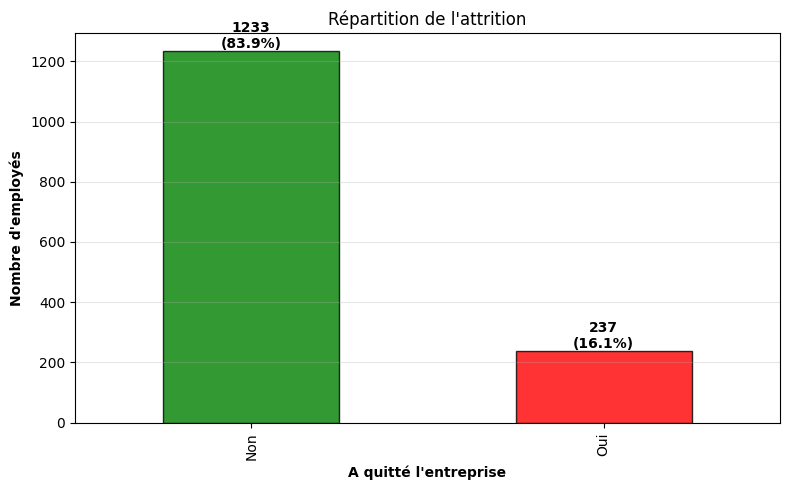

In [12]:
counts = df["a_quitte_l_entreprise"].value_counts()
ax = counts.plot(
    kind="bar", 
    title="Répartition de l'attrition",
    color=['green', 'red'], 
    figsize=(8, 5),
    edgecolor='black',
    alpha=0.8
)
total = counts.sum()
for i, v in enumerate(counts):
    pct = (v / total * 100)
    ax.text(i, v + 10, f'{v}\n({pct:.1f}%)', ha='center', fontweight='bold')

ax.set_xlabel("A quitté l'entreprise", fontweight='bold')
ax.set_ylabel("Nombre d'employés", fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### Interprétation

- Le phénomène d’attrition concerne une minorité d’employés.

- Cela confirme la nécessité d’une approche adaptée au déséquilibre des classes.

### Comparaison du taux d'attrition sur variables numériques

/var/folders/xw/0n7rfwdx3xsfwq5zv62wb1500000gn/T/ipykernel_4832/595259776.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["Non", "Oui"], patch_artist=True)


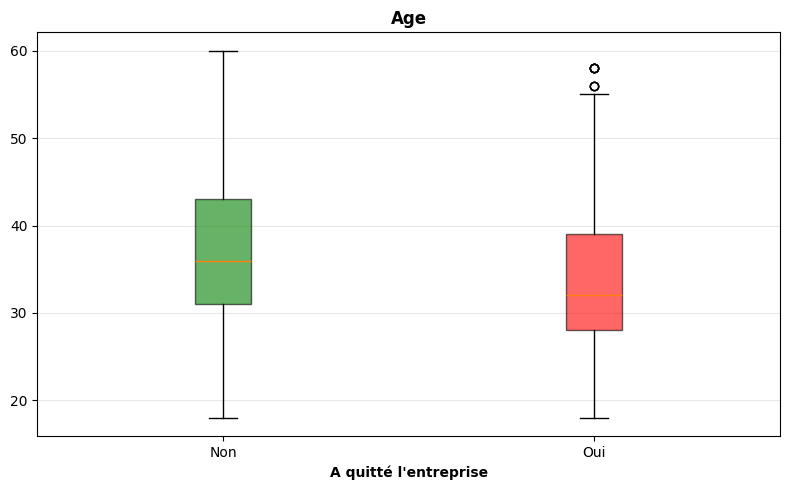

/var/folders/xw/0n7rfwdx3xsfwq5zv62wb1500000gn/T/ipykernel_4832/595259776.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["Non", "Oui"], patch_artist=True)


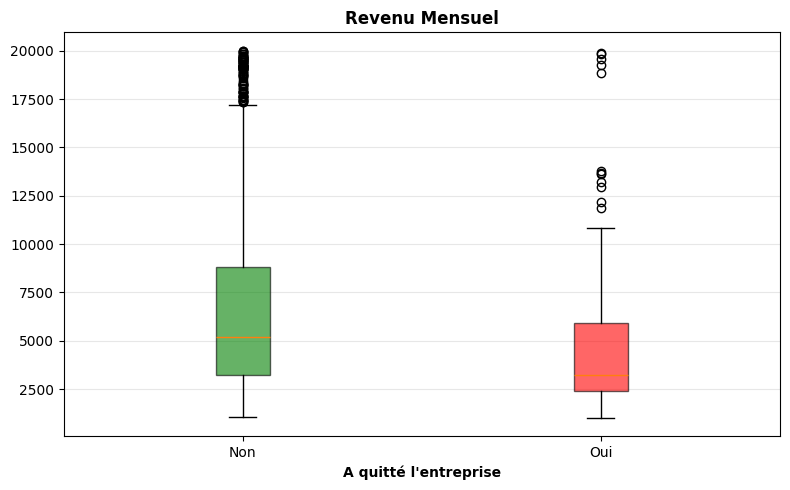

/var/folders/xw/0n7rfwdx3xsfwq5zv62wb1500000gn/T/ipykernel_4832/595259776.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["Non", "Oui"], patch_artist=True)


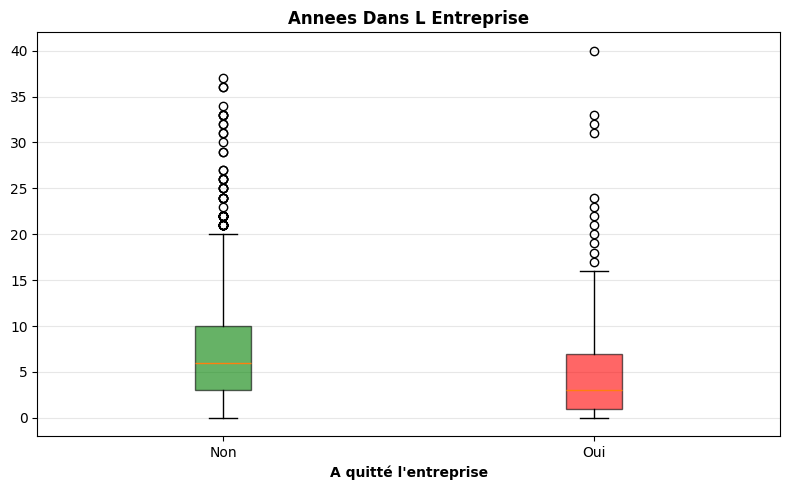

In [13]:
for col in ["age", "revenu_mensuel", "annees_dans_l_entreprise"]:
    fig, ax = plt.subplots(figsize=(8, 5))
    
    # Données séparées
    data = [df[df["a_quitte_l_entreprise"]=="Non"][col],
            df[df["a_quitte_l_entreprise"]=="Oui"][col]]
    
    bp = ax.boxplot(data, labels=["Non", "Oui"], patch_artist=True)
    
    # Couleurs 
    for patch, color in zip(bp['boxes'], ['green', 'red']):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    
    ax.set_title(col.replace('_', ' ').title(), fontweight='bold')
    ax.set_xlabel("A quitté l'entreprise", fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

### Interprétation

Les boxplots révèlent des différences notables entre les employés partis et restés :
- **Âge** : Distribution similaire, l'âge n'est pas un facteur discriminant majeur
- **Revenu mensuel** : Les employés partis ont tendance à avoir des revenus plus faibles (médiane inférieure)
- **Ancienneté** : Les départs sont plus fréquents chez les employés avec moins d'années dans l'entreprise

### Taux d’attrition par variable catégorielle

In [14]:
# First, create a numeric version of the target variable
df['attrition_numeric'] = (df['a_quitte_l_entreprise'] == 'Oui').astype(int)

for col in ["departement", "poste", "niveau_education"]:
    if col in df.columns:
        display(
            df.groupby(col)['attrition_numeric']
            .agg(['count', 'mean'])
            .sort_values('mean', ascending=False)
            .head(10)
        )

,count,mean
departement,,
Commercial,446,0.206278
Ressources Humaines,63,0.190476
Consulting,961,0.138398


,count,mean
poste,,
Représentant Commercial,83,0.397590
Consultant,259,0.239382
Ressources Humaines,52,0.230769
Cadre Commercial,326,0.174847
Assistant de Direction,292,0.160959
Tech Lead,145,0.068966
Manager,131,0.068702
Senior Manager,102,0.049020
Directeur Technique,80,0.025000


,count,mean
niveau_education,,
1,170,0.182353
3,572,0.173077
2,282,0.156028
4,398,0.145729
5,48,0.104167


### Interprétation

**Département** : Le Commercial présente le taux le plus élevé (20,6%), contre 13,8% pour le Consulting.

**Poste** : Forte disparité selon le niveau hiérarchique :
- Postes à risque : Représentant Commercial (39,8%), Consultant (23,9%)
- Postes stables : Directeur Technique (2,5%), Senior Manager (4,9%)

**Niveau d'éducation** : Relation inverse entre qualification et attrition (18,2% pour niveau 1 vs 10,4% pour niveau 5).

**Action prioritaire** : Investiguer les causes du turnover des Représentants Commerciaux (taux proche de 40%).

### Sauvegarde du dataframe pour l'étape 2


In [15]:
df.to_csv('../data/combined_df.csv', index=False)
